In [31]:
import sys
from pathlib import Path

current_dir = Path.cwd()

root_dir = current_dir
while not (root_dir / 'utils').is_dir() and root_dir != root_dir.parent:
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay
from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from sklearn.utils import resample
from utils.model_manager import save_model_package

In [33]:
class LinearSVMScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=100):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "lambda_param": self.lambda_param,
            "n_iters": self.n_iters
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def fit(self, X, y):
        
        y = np.array(y).flatten()
        n_samples, n_features = X.shape
        
        # Conver label to 1 and -1 for SVM
        y_ = np.where(y <= 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            margins = y_ * (X.dot(self.w) - self.b)
            
            misclassified = margins < 1
            
            y_mis = y_ * misclassified
            
            dw = 2 * self.lambda_param * self.w - (X.T.dot(y_mis) / n_samples)
            db = np.sum(y_mis) / n_samples
            
            # Update weight
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
        return self

    def predict(self, X, threshold=0.0):
        approx = X.dot(self.w) - self.b
        # return np.where(approx < 0, 0, 1)
        return np.where(approx < threshold, 0, 1)

In [34]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

In [35]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (21906, 5001)
X_test : (5477, 5001)
y_train: (21906,)
y_test : (5477,)


In [36]:
svm_param_grid = {
    'learning_rate': [0.1, 0.01],  
    'lambda_param': [0.01, 0.001],
    'n_iters': [1000, 2000]        
}

In [37]:
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

svm_scratch = LinearSVMScratch()


svm_grid_search = CustomGridSearchCV(
    estimator=svm_scratch, 
    param_grid=svm_param_grid, 
    cv=cv, 
    scoring='f1'
)
svm_grid_search.fit(X_train, y_train)

Bắt đầu GridSearchCV: 8 tổ hợp tham số, 3 folds.
[1/8] Params: {'learning_rate': 0.1, 'lambda_param': 0.01, 'n_iters': 1000} --> f1: 0.5135
[2/8] Params: {'learning_rate': 0.1, 'lambda_param': 0.01, 'n_iters': 2000} --> f1: 0.7658
[3/8] Params: {'learning_rate': 0.1, 'lambda_param': 0.001, 'n_iters': 1000} --> f1: 0.8663
[4/8] Params: {'learning_rate': 0.1, 'lambda_param': 0.001, 'n_iters': 2000} --> f1: 0.9358
[5/8] Params: {'learning_rate': 0.01, 'lambda_param': 0.01, 'n_iters': 1000} --> f1: 0.0000
[6/8] Params: {'learning_rate': 0.01, 'lambda_param': 0.01, 'n_iters': 2000} --> f1: 0.0000
[7/8] Params: {'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 1000} --> f1: 0.0000
[8/8] Params: {'learning_rate': 0.01, 'lambda_param': 0.001, 'n_iters': 2000} --> f1: 0.0000

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'lambda_param': 0.001, 'n_iters': 2000}
-> Điểm f1 TỐT NHẤT: 0.9358


In [38]:
best_svm_model = svm_grid_search.best_estimator_
best_svm_params = svm_grid_search.best_params_

In [39]:
approx_values = X_test.dot(best_svm_model.w) - best_svm_model.b

candidate_thresholds = np.linspace(0.0, 5.0, 100)

target_threshold = 0.0
closest_fpr = 1.0

print(f"{'Threshold':<12}{'FP':<8}{'TN':<8}{'FPR (%)':<12}{'TPR (Recall) (%)':<15}")
print("-" * 55)

for th in candidate_thresholds:
    preds = np.where(approx_values < th, 0, 1)

    tp_c = np.sum((y_test == 1) & (preds == 1))
    fp_c = np.sum((y_test == 0) & (preds == 1))
    tn_c = np.sum((y_test == 0) & (preds == 0))
    fn_c = np.sum((y_test == 1) & (preds == 0))
    
    fpr_c = fp_c / (fp_c + tn_c) if (fp_c + tn_c) > 0 else 0
    tpr_c = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0
    
    if th % 0.5 == 0 or (0.005 <= fpr_c <= 0.02):
        print(f"{th:<12.2f}{fp_c:<8}{tn_c:<8}{fpr_c*100:<12.2f}{tpr_c*100:<15.2f}")
        
    if abs(fpr_c - 0.01) < abs(closest_fpr - 0.01):
        closest_fpr = fpr_c
        target_threshold = th

print(f"Threshold tốt nhất: {target_threshold:.4f}")
print(f"FPR đạt được tại threshold đso: {closest_fpr*100:.2f}%")

Threshold   FP      TN      FPR (%)     TPR (Recall) (%)
-------------------------------------------------------
0.00        208     2677    7.21        94.21          
0.35        47      2838    1.63        83.18          
0.40        37      2848    1.28        80.25          
0.45        28      2857    0.97        76.70          
0.51        25      2860    0.87        72.96          
0.56        22      2863    0.76        68.98          
0.61        18      2867    0.62        64.85          
0.66        16      2869    0.55        60.07          
5.00        0       2885    0.00        0.00           
Threshold tốt nhất: 0.4545
FPR đạt được tại threshold đso: 0.97%


In [40]:
y_pred = best_svm_model.predict(X_test,0.4545)

In [41]:
metrics_svm = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred)
}
print(f"Precision : {metrics_svm['Precision']:.4f}")
print(f"Accuracy  : {metrics_svm['Accuracy']:.4f}")
print(f"Recall    : {metrics_svm['Recall']:.4f}")
print(f"F1 Score  : {metrics_svm['F1_Score']:.4f}")

Precision : 0.9861
Accuracy  : 0.8848
Recall    : 0.7674
F1 Score  : 0.8631


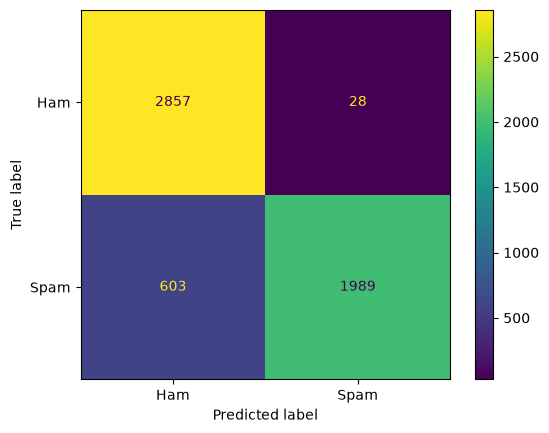

In [42]:
cm = confusion_matrix(y_test, y_pred)

# Visualize prediction results
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
).plot()

plt.show()

- Positive: Spam
- Negative: Ham

- TP: Thư Spam (Positive) được đoán đúng là Spam
- TN: Thư Ham (Negative) được đoán đúng là Ham
- FP: Thư Ham (Negative) nhưng mô hình lại giật mình báo là Spam (Positive)
- FN: Thư Spam (Positive) nhưng mô hình lại tưởng là Ham (Negative)

In [43]:
from sklearn.svm import LinearSVC

Bắt đầu GridSearchCV: 3 tổ hợp tham số, 3 folds.
[1/3] Params: {'C': 0.1, 'max_iter': 1000} --> f1: 0.9810
[2/3] Params: {'C': 1, 'max_iter': 1000} --> f1: 0.9828
[3/3] Params: {'C': 10, 'max_iter': 1000} --> f1: 0.9784

-> Tham số TỐT NHẤT: {'C': 1, 'max_iter': 1000}
-> Điểm f1 TỐT NHẤT: 0.9828
Tham số tốt nhất của LinearSVC: {'C': 1, 'max_iter': 1000}
Accuracy : 0.9836
Precision: 0.9786
Recall   : 0.9869
F1 Score : 0.9827


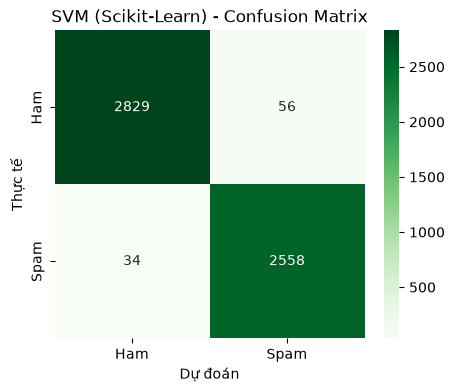

In [44]:
import joblib
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

X_train_full = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test_full = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train_full = joblib.load('./data/ready_for_train/y_train.pkl').values
y_test_full = joblib.load('./data/ready_for_train/y_test.pkl').values

svc_model = LinearSVC(random_state=42, dual=False)

param_grid_svc = {
    'C': [0.1, 1, 10], 
    'max_iter': [1000]
}

grid_search_svc = CustomGridSearchCV(estimator=svc_model, param_grid=param_grid_svc, cv=cv)

grid_search_svc.fit(X_train_full, y_train_full)

best_svc_model = grid_search_svc.best_estimator_
best_params_svc = grid_search_svc.best_params_
print(f"Tham số tốt nhất của LinearSVC: {best_params_svc}")

y_pred_sklearn = best_svc_model.predict(X_test_full)

acc_sk = accuracy_score(y_test_full, y_pred_sklearn)
prec_sk = precision_score(y_test_full, y_pred_sklearn)
rec_sk = recall_score(y_test_full, y_pred_sklearn)
f1_sk = f1_score(y_test_full, y_pred_sklearn)

print(f"Accuracy : {acc_sk:.4f}")
print(f"Precision: {prec_sk:.4f}")
print(f"Recall   : {rec_sk:.4f}")
print(f"F1 Score : {f1_sk:.4f}")

cm_sk = confusion_matrix(y_test_full, y_pred_sklearn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('SVM (Scikit-Learn) - Confusion Matrix')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [45]:
# =====================================================
# Save Model
# =====================================================

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred)
}

model_path = save_model_package(
    model=None,
    model_name="Linear SVM Scratch",
    best_params=best_svm_params,
    metrics=metrics
)

print("Saved:", model_path)

Saved: models\Linear_SVM_Scratch.pkl
